In [1]:
import sys
sys.path.append("..")

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import Counter
import random
import warnings
warnings.filterwarnings("ignore")

from src.config import DATA_RAW_DIR, LABELS_FOLDER, IMAGES_FOLDER

# Reproducibility
random.seed(42)
np.random.seed(42)

print("All imports successful!")

All imports successful!


In [2]:
SPLITS = {
    "train" : "VisDrone2019-DET-train",
    "val"   : "VisDrone2019-DET-val",
    "test"  : "VisDrone2019-DET-test-dev",
}

VISDRONE_CLASSES = {
    0:"ignored", 1:"pedestrian", 2:"people",
    3:"bicycle", 4:"car",        5:"van",
    6:"truck",   7:"tricycle",   8:"awning-tricycle",
    9:"bus",     10:"motor",     11:"others"
}

print(f"{'Split':<8} {'Images':>8} {'Labels':>8} {'Match':>6}")
print("─" * 36)

split_info = {}
for name, folder in SPLITS.items():
    img_dir = DATA_RAW_DIR / folder / IMAGES_FOLDER
    lbl_dir = DATA_RAW_DIR / folder / LABELS_FOLDER
    imgs    = list(img_dir.glob("*.jpg"))
    lbls    = list(lbl_dir.glob("*.txt")) if lbl_dir.exists() else []
    match   = "✅" if len(imgs) == len(lbls) else "⚠️"
    split_info[name] = {"imgs": imgs, "lbls": lbls}
    print(f"{name:<8} {len(imgs):>8} {len(lbls):>8} {match:>6}")

print(f"\nTotal images: {sum(len(v['imgs']) for v in split_info.values()):,}")

Split      Images   Labels  Match
────────────────────────────────────
train        6471     6471      ✅
val           548      548      ✅
test         1610     1610      ✅

Total images: 8,629


In [3]:
class_counts = {split: Counter() for split in SPLITS}

for split_name, folder in SPLITS.items():
    lbl_dir = DATA_RAW_DIR / folder / LABELS_FOLDER
    if not lbl_dir.exists():
        continue
    for lbl_file in lbl_dir.glob("*.txt"):
        with open(lbl_file) as f:
            for line in f:
                vals = line.strip().split()
                if vals:
                    class_counts[split_name][int(vals[0])] += 1

# Print table
print(f"{'Class':<5} {'Name':<20} {'Train':>10} {'Val':>8} {'Test':>8}")
print("─" * 56)
all_ids = sorted(set().union(*[c.keys() for c in class_counts.values()]))
for cid in all_ids:
    name  = VISDRONE_CLASSES.get(cid, "unknown")
    tr    = class_counts["train"].get(cid, 0)
    va    = class_counts["val"].get(cid, 0)
    te    = class_counts["test"].get(cid, 0)
    print(f"{cid:<5} {name:<20} {tr:>10,} {va:>8,} {te:>8,}")

print(f"\n{'TOTAL':<26} {sum(class_counts['train'].values()):>10,} "
      f"{sum(class_counts['val'].values()):>8,} "
      f"{sum(class_counts['test'].values()):>8,}")

Class Name                      Train      Val     Test
────────────────────────────────────────────────────────
0     ignored                  79,337    8,844   21,006
1     pedestrian               27,059    5,125    6,376
2     people                   10,480    1,287    1,302
3     bicycle                 144,867   14,064   28,074
4     car                      24,956    1,975    5,771
5     van                      12,875      750    2,659
6     truck                     4,812    1,045      530
7     tricycle                  3,246      532      599
8     awning-tricycle           5,926      251    2,940
9     bus                      29,647    4,886    5,845

TOTAL                         343,205   38,759   75,102


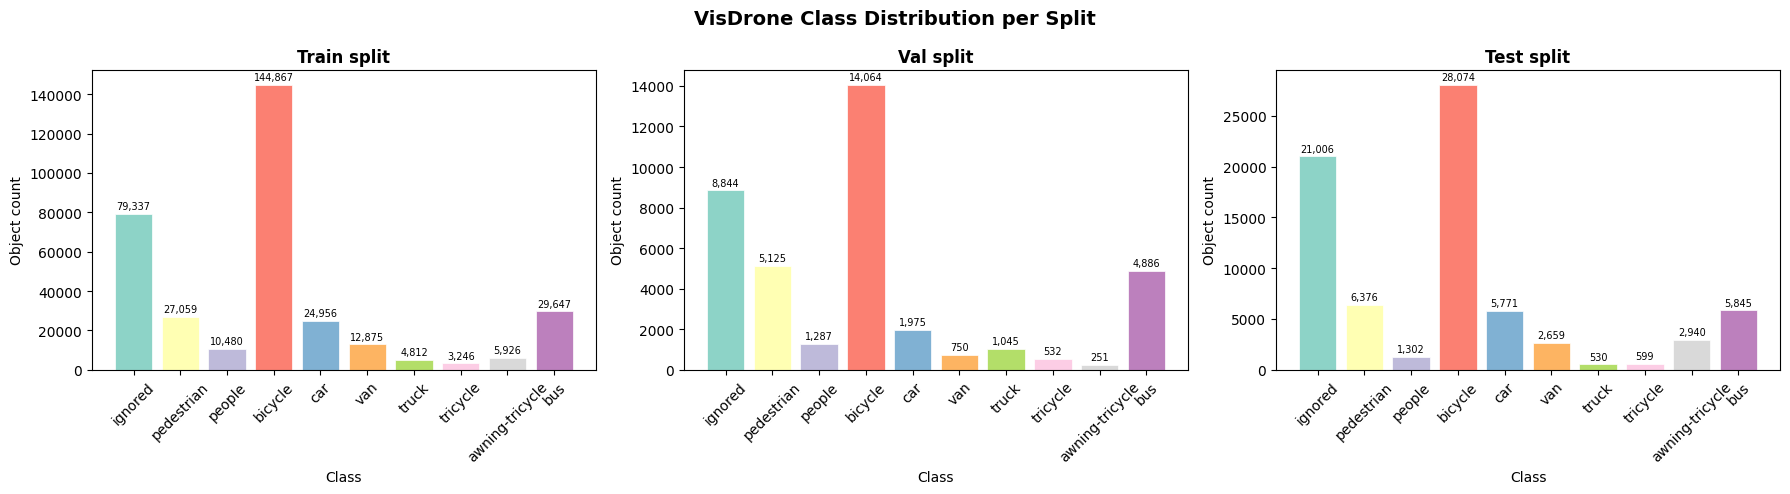

Saved → assets/sample_images/class_distribution.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("VisDrone Class Distribution per Split", fontsize=14, fontweight="bold")

colors = plt.cm.Set3(np.linspace(0, 1, 12))

for ax, (split_name, counts) in zip(axes, class_counts.items()):
    names  = [VISDRONE_CLASSES.get(i, str(i)) for i in sorted(counts)]
    values = [counts[i] for i in sorted(counts)]
    bars   = ax.bar(names, values, color=colors[:len(names)], edgecolor="white", linewidth=0.5)
    ax.set_title(f"{split_name.capitalize()} split", fontweight="bold")
    ax.set_xlabel("Class")
    ax.set_ylabel("Object count")
    ax.tick_params(axis="x", rotation=45)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig("../assets/sample_images/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → assets/sample_images/class_distribution.png")

Image width  — min: 960  max: 2000  avg: 1533
Image height — min: 540 max: 1500 avg: 1023


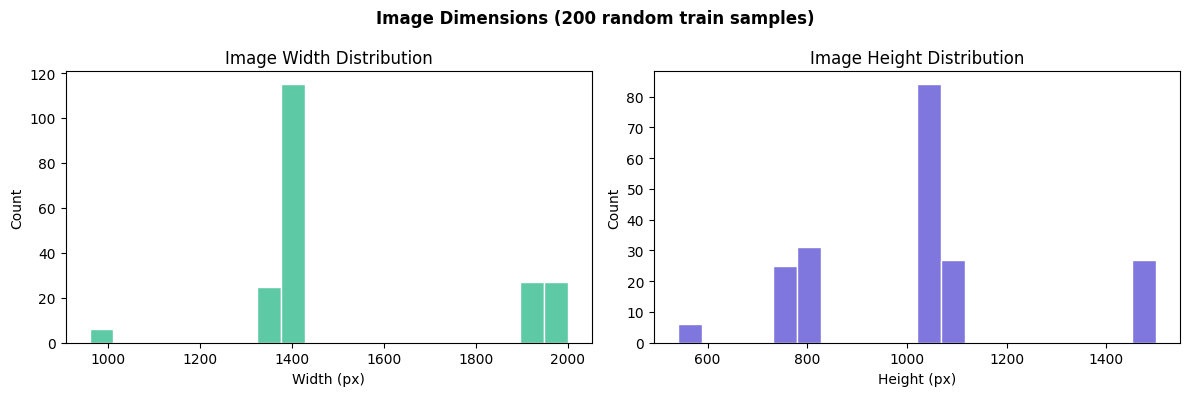

In [5]:
img_dir = DATA_RAW_DIR / "VisDrone2019-DET-train" / IMAGES_FOLDER
sample_imgs = random.sample(list(img_dir.glob("*.jpg")), 200)

widths, heights = [], []
for img_path in sample_imgs:
    img = cv2.imread(str(img_path))
    if img is not None:
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)

print(f"Image width  — min: {min(widths)}  max: {max(widths)}  avg: {np.mean(widths):.0f}")
print(f"Image height — min: {min(heights)} max: {max(heights)} avg: {np.mean(heights):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=20, color="#5DCAA5", edgecolor="white")
axes[0].set_title("Image Width Distribution")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Count")

axes[1].hist(heights, bins=20, color="#7F77DD", edgecolor="white")
axes[1].set_title("Image Height Distribution")
axes[1].set_xlabel("Height (px)")
axes[1].set_ylabel("Count")

plt.suptitle("Image Dimensions (200 random train samples)", fontweight="bold")
plt.tight_layout()
plt.savefig("../assets/sample_images/image_size_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Bounding box width  — avg: 39.8px  median: 27.0px
Bounding box height — avg: 39.1px  median: 29.0px
Bounding box area   — avg: 2561px²  median: 740px²

Tiny objects (<32×32px): 15,630 / 26,802 = 58.3%


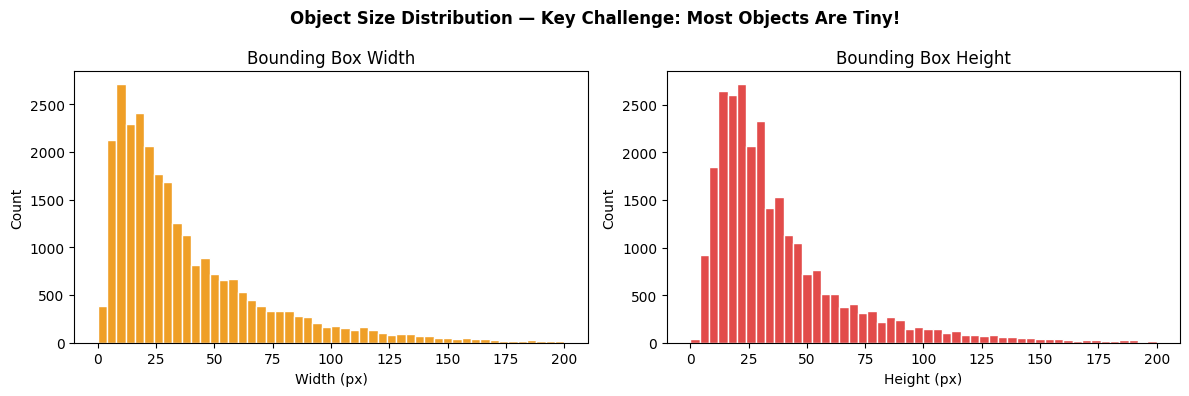

In [6]:
lbl_dir = DATA_RAW_DIR / "VisDrone2019-DET-train" / LABELS_FOLDER
img_dir = DATA_RAW_DIR / "VisDrone2019-DET-train" / IMAGES_FOLDER

box_widths, box_heights, box_areas = [], [], []
sample_files = random.sample(list(lbl_dir.glob("*.txt")), 500)

for lbl_file in sample_files:
    img_file = img_dir / (lbl_file.stem + ".jpg")
    img      = cv2.imread(str(img_file))
    if img is None:
        continue
    ih, iw  = img.shape[:2]
    with open(lbl_file) as f:
        for line in f:
            vals = line.strip().split()
            if len(vals) == 5:
                _, cx, cy, w, h = map(float, vals)
                box_widths.append(w * iw)
                box_heights.append(h * ih)
                box_areas.append((w * iw) * (h * ih))

print(f"Bounding box width  — avg: {np.mean(box_widths):.1f}px  median: {np.median(box_widths):.1f}px")
print(f"Bounding box height — avg: {np.mean(box_heights):.1f}px  median: {np.median(box_heights):.1f}px")
print(f"Bounding box area   — avg: {np.mean(box_areas):.0f}px²  median: {np.median(box_areas):.0f}px²")
tiny = sum(1 for a in box_areas if a < 32*32)
print(f"\nTiny objects (<32×32px): {tiny:,} / {len(box_areas):,} = {100*tiny/len(box_areas):.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(box_widths,  bins=50, color="#EF9F27", edgecolor="white", range=(0, 200))
axes[0].set_title("Bounding Box Width")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Count")

axes[1].hist(box_heights, bins=50, color="#E24B4A", edgecolor="white", range=(0, 200))
axes[1].set_title("Bounding Box Height")
axes[1].set_xlabel("Height (px)")
axes[1].set_ylabel("Count")

plt.suptitle("Object Size Distribution — Key Challenge: Most Objects Are Tiny!", fontweight="bold")
plt.tight_layout()
plt.savefig("../assets/sample_images/bbox_size_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

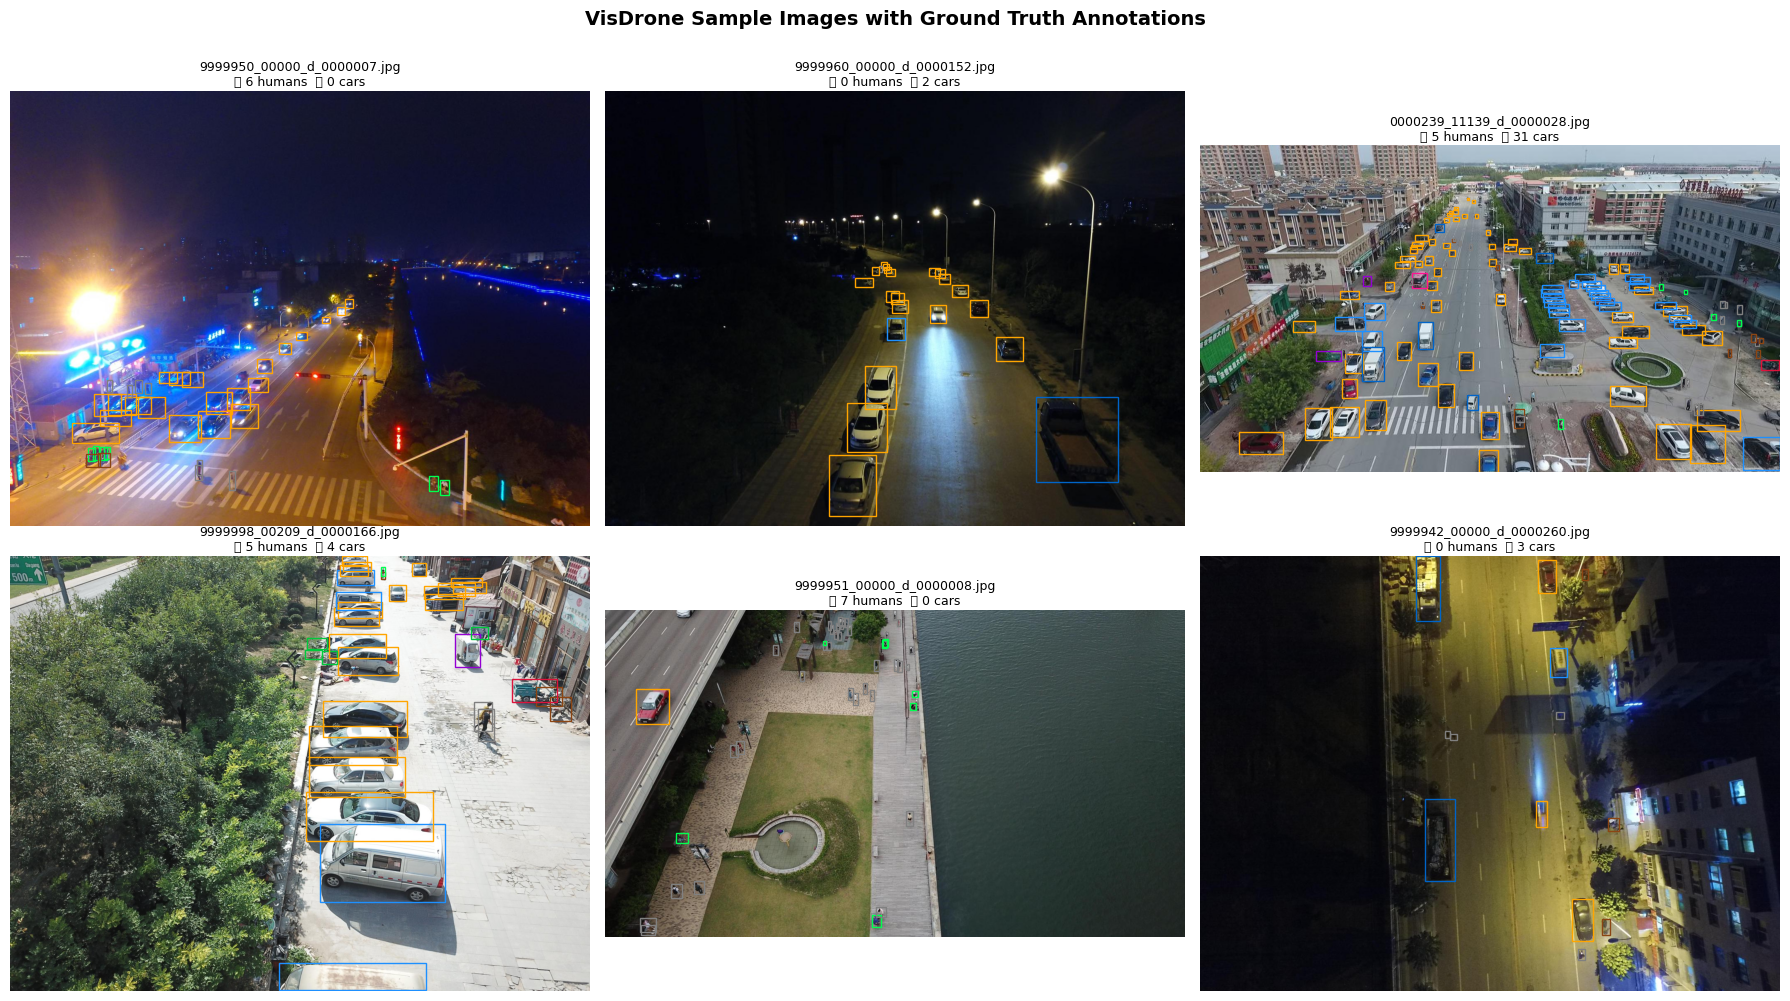

Saved → assets/sample_images/sample_annotations_grid.png


In [7]:
img_dir = DATA_RAW_DIR / "VisDrone2019-DET-train" / IMAGES_FOLDER
lbl_dir = DATA_RAW_DIR / "VisDrone2019-DET-train" / LABELS_FOLDER

CLASS_COLORS_VIS = {
    0:(128,128,128), 1:(0,255,80),  2:(0,200,60),
    3:(255,165,0),   4:(30,144,255),5:(0,100,200),
    6:(220,20,60),   7:(148,0,211), 8:(255,20,147),
    9:(139,69,19),   10:(0,206,209),11:(169,169,169)
}

sample_imgs = random.sample(list(img_dir.glob("*.jpg")), 6)
fig, axes   = plt.subplots(2, 3, figsize=(18, 10))
axes        = axes.flatten()

for ax, img_path in zip(axes, sample_imgs):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    ih, iw  = img_rgb.shape[:2]

    lbl_path = lbl_dir / (img_path.stem + ".txt")
    ax.imshow(img_rgb)

    humans, cars = 0, 0
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                vals = line.strip().split()
                if len(vals) != 5:
                    continue
                cid, cx, cy, w, h = int(vals[0]), *map(float, vals[1:])
                x1 = (cx - w/2) * iw
                y1 = (cy - h/2) * ih
                bw = w * iw
                bh = h * ih
                color = [c/255 for c in CLASS_COLORS_VIS.get(cid, (255,255,255))]
                rect  = patches.Rectangle((x1,y1), bw, bh,
                                          linewidth=1, edgecolor=color, facecolor="none")
                ax.add_patch(rect)
                if cid in (1, 2): humans += 1
                if cid in (4, 5): cars   += 1

    ax.set_title(f"{img_path.name}\n👤 {humans} humans  🚗 {cars} cars",
                 fontsize=9, pad=4)
    ax.axis("off")

plt.suptitle("VisDrone Sample Images with Ground Truth Annotations",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../assets/sample_images/sample_annotations_grid.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → assets/sample_images/sample_annotations_grid.png")

In [8]:
summary = """
╔══════════════════════════════════════════════════════════════╗
║           DATASET UNDERSTANDING SUMMARY (Task-01)           ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset   : VisDrone2019-DET (Kaggle — YOLO pre-formatted) ║
║  Train     : 6,471 images                                   ║
║  Val       :   548 images                                   ║
║  Test      : 1,610 images                                   ║
║  Classes   : 12 (we use pedestrian + car = 2)               ║
╠══════════════════════════════════════════════════════════════╣
║  KEY CHALLENGES:                                            ║
║  1. Tiny objects — most humans are < 20×20px                ║
║  2. High density — 100s of people per image                 ║
║  3. Class imbalance — pedestrians >> cars >> others         ║
║  4. Occlusion — objects overlap heavily in crowds           ║
║  5. Varied altitude — scale changes drastically             ║
║  6. Lighting variation — day/night/shadows                  ║
╠══════════════════════════════════════════════════════════════╣
║  PREPROCESSING DECISIONS:                                   ║
║  • Labels already in YOLO format — no conversion needed     ║
║  • Filter to 2 classes: pedestrian (0,1,2) and car (3,4,5) ║
║  • Image resize to 640×640 (YOLO standard)                  ║
║  • Augmentation: flip, mosaic, scale (handled by YOLO)      ║
╚══════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════╗
║           DATASET UNDERSTANDING SUMMARY (Task-01)           ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset   : VisDrone2019-DET (Kaggle — YOLO pre-formatted) ║
║  Train     : 6,471 images                                   ║
║  Val       :   548 images                                   ║
║  Test      : 1,610 images                                   ║
║  Classes   : 12 (we use pedestrian + car = 2)               ║
╠══════════════════════════════════════════════════════════════╣
║  KEY CHALLENGES:                                            ║
║  1. Tiny objects — most humans are < 20×20px                ║
║  2. High density — 100s of people per image                 ║
║  3. Class imbalance — pedestrians >> cars >> others         ║
║  4. Occlusion — objects overlap heavily in crowds           ║
║  5. Varied altitude — scale changes drastically             ║
║  6. Lighting variation — day/night